<h1 style="color:green">Spam Classifier</h1>

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv("SMSSpamCollection.tsv", sep="\t") 

In [4]:
df.head()

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2


In [5]:
df = df.iloc[:,:-2]

In [6]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Data Cleaning

In [8]:
import re  # re = Regular Expression module; used for pattern matching and text cleaning (e.g., removing punctuation, digits, etc.)
import nltk  # nltk = Natural Language Toolkit; a library for working with human language data (text processing, NLP tasks)
from nltk.corpus import stopwords  # Importing 'stopwords' list from NLTK's corpus module; used to remove common words like 'the', 'is', 'in', etc.
from nltk.stem.snowball import SnowballStemmer  # Importing the SnowballStemmer class; used for stemming, i.e., reducing words to their root form (e.g., 'running' → 'run')

In [9]:
#nltk.download('stopwords') # Need to download first time 

In [10]:
sn = SnowballStemmer("english")
stop = set(stopwords.words('english'))

In [11]:
#nltk.download('punkt')  # Download required for word_tokenize

In [12]:
def clean_text(sms): 
    sms = sms.lower()
    sms = re.sub("[^a-z0-9]", ' ', sms) 
    sms = nltk.word_tokenize(sms)
    sms = [t for t in sms if len(t)>1]
    sms = [word for word in sms if word not in stop]
    sms = [sn.stem(word) for word in sms]
    sms = ' '.join(sms)
    return sms

In [13]:
clean_text("Get is .. are.. playing they UNLIMITED <!!!>,,,??? Free data played 100GB.. at TK 0")

'get play unlimit free data play 100gb tk'

In [14]:
df['message'] = df['message'].apply(clean_text)

In [15]:
df['message']

0       go jurong point crazi avail bugi great world l...
1                                     ok lar joke wif oni
2       free entri wkli comp win fa cup final tkts 21s...
3                           dun say earli hor alreadi say
4                    nah think goe usf live around though
                              ...                        
5567    2nd time tri contact 750 pound prize claim eas...
5568                                  go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: message, Length: 5572, dtype: object

In [16]:
#pip install wordcloud

## WordCloud

In [18]:
from wordcloud import WordCloud

In [19]:
hamdata = df[df['label']=='ham']
hamdata = hamdata['message']

In [20]:
hamdata

0       go jurong point crazi avail bugi great world l...
1                                     ok lar joke wif oni
3                           dun say earli hor alreadi say
4                    nah think goe usf live around though
6           even brother like speak treat like aid patent
                              ...                        
5565                                              huh lei
5568                                  go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: message, Length: 4825, dtype: object

In [21]:
def wordCloud(data): 
    words = ' '.join(data) 
    wc = WordCloud() 
    wc = WordCloud(background_color='white')
    wc = wc.generate(words)

    plt.figure(figsize=(10,8))
    plt.imshow(wc)
    plt.axis("off")
    plt.show()

Ham Data Words :


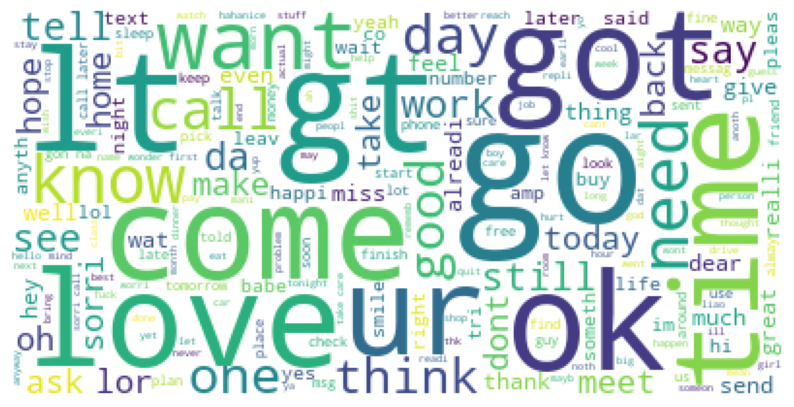

In [22]:
print("Ham Data Words :")
wordCloud(hamdata)

In [23]:
spamdata = df[df['label']=='spam']
spamdata = spamdata['message']

Spam Data Words :


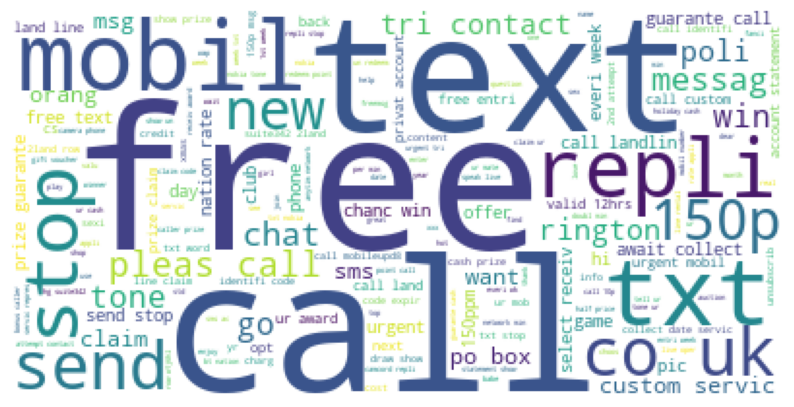

In [24]:
print("Spam Data Words :")
wordCloud(spamdata)

## Featurization

In [26]:
from sklearn.feature_extraction.text import CountVectorizer

In [27]:
cv = CountVectorizer() # cv = count vectorizer

In [28]:
X = cv.fit_transform(df['message'])

In [29]:
X.shape

(5572, 7242)

In [30]:
cv = CountVectorizer(max_features=5000) # cv = count vectorizer

In [31]:
X = cv.fit_transform(df['message']).toarray()

In [32]:
X.shape

(5572, 5000)

In [33]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [34]:
y = pd.get_dummies(df['label'])
y = y['spam'].values

In [35]:
y

array([False, False,  True, ..., False, False, False])

In [36]:
y = y.astype(int)

In [37]:
y

array([0, 0, 1, ..., 0, 0, 0])

## Model Building

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [41]:
from sklearn.naive_bayes import MultinomialNB

In [42]:
model = MultinomialNB()

In [43]:
model.fit(X_train, y_train)

MultinomialNB()

In [44]:
y_pred = model.predict(X_test)

In [45]:
pd.DataFrame({'Actual': y_test, 'Predicted':y_test}).head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,0,0
4,0,0
5,0,0
6,1,1
7,0,0
8,0,0
9,0,0


## Evaluation

In [47]:
print("Accuracy on Traing Data ")
model.score(X_train, y_train)

Accuracy on Traing Data 


0.9916984518734575

In [48]:
print("Accuracy on Test Data ")
model.score(X_test, y_test)

Accuracy on Test Data 


0.9883408071748879

In [49]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report

In [50]:
confusion_matrix(y_test, y_pred)

array([[949,   6],
       [  7, 153]], dtype=int64)

In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       955
           1       0.96      0.96      0.96       160

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [52]:
f1_score(y_test, y_pred)

0.9592476489028213